In [1]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.api as sm

KeyboardInterrupt: 

In [ ]:
'''
url = ("https://ssd-api.jpl.nasa.gov/sbdb_query.api"
       "?fields=full_name,H,diameter,albedo,e,a,q,i,n")
'''

'\nurl = ("https://ssd-api.jpl.nasa.gov/sbdb_query.api"\n       "?fields=full_name,H,diameter,albedo,e,a,q,i,n")\n'

In [ ]:
#r = requests.get(url)
#r.raise_for_status()

In [ ]:
#j = r.json()
#df = pd.DataFrame(j['data'], columns=j['fields'])
#df.tail()
df= pd.read_csv("data/raw/asteroid_data.csv" )

In [ ]:
df.describe()

,H,diameter,albedo,e,a,q,i,n
count,1.548187e+06,139687.000000,138480.000000,1.552759e+06,1.550997e+06,1.552759e+06,1.552759e+06,1.550997e+06
mean,1.764210e+01,5.460632,0.130105,1.606256e-01,-2.793690e+05,2.413547e+00,9.515451e+00,2.348199e-01
std,1.907690e+00,9.309314,0.110369,1.024937e-01,3.479231e+08,2.215584e+00,8.305899e+00,8.496533e-02
min,-1.260000e+00,0.002500,0.001000,0.000000e+00,-4.333000e+11,1.000000e-03,1.000000e-02,3.455000e-18
25%,1.672000e+01,2.764000,0.053000,9.290000e-02,2.400000e+00,1.972000e+00,4.380000e+00,1.869000e-01
50%,1.764000e+01,3.950000,0.078000,1.477000e-01,2.669000e+00,2.245000e+00,7.910000e+00,2.261000e-01
75%,1.854000e+01,5.732000,0.189000,2.047000e-01,3.030000e+00,2.595000e+00,1.272000e+01,2.651000e-01
max,3.406000e+01,939.400000,1.000000,6.141400e+00,1.619000e+06,8.064200e+01,1.792100e+02,7.273000e+00


In [ ]:
df.dtypes

full_name        str
H            float64
diameter     float64
albedo       float64
e            float64
a            float64
q            float64
i            float64
n            float64
dtype: object

In [ ]:
num_cols = ["H", "diameter", "albedo", "e", "a", "q", "i", "n"]
df[num_cols] = df[num_cols].apply(pd.to_numeric, errors='coerce')

In [ ]:
df.dtypes

full_name        str
H            float64
diameter     float64
albedo       float64
e            float64
a            float64
q            float64
i            float64
n            float64
dtype: object

In [ ]:
df.shape

(1552759, 9)

In [ ]:
df.isna().sum()

full_name          0
H               4572
diameter     1413072
albedo       1414279
e                  0
a               1762
q                  0
i                  0
n               1762
dtype: int64

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1552759 entries, 0 to 1552758
Data columns (total 9 columns):
 #   Column     Non-Null Count    Dtype  
---  ------     --------------    -----  
 0   full_name  1552759 non-null  str    
 1   H          1548187 non-null  float64
 2   diameter   139687 non-null   float64
 3   albedo     138480 non-null   float64
 4   e          1552759 non-null  float64
 5   a          1550997 non-null  float64
 6   q          1552759 non-null  float64
 7   i          1552759 non-null  float64
 8   n          1550997 non-null  float64
dtypes: float64(8), str(1)
memory usage: 106.6 MB


In [ ]:
(df.isnull().mean()*100).sort_values(ascending=False)

albedo       91.081681
diameter     91.003948
H             0.294444
n             0.113475
a             0.113475
full_name     0.000000
e             0.000000
q             0.000000
i             0.000000
dtype: float64

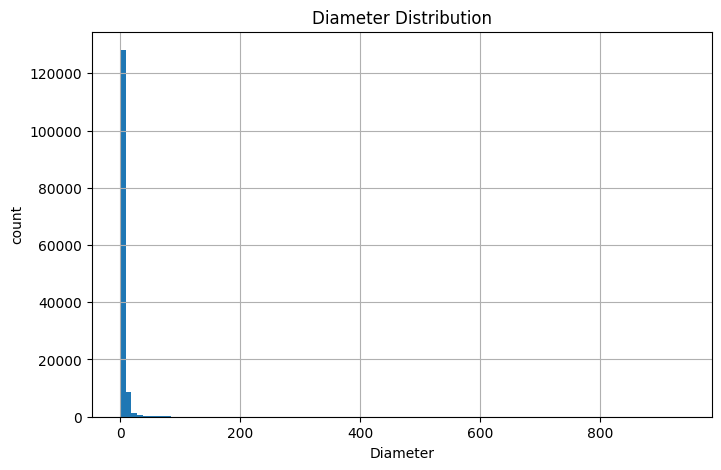

In [ ]:
df["diameter"].hist(bins=100, figsize=(8, 5))
plt.title("Diameter Distribution")
plt.xlabel("Diameter")
plt.ylabel("count")
plt.show()

In [ ]:
model_df = df.dropna(
    subset=["H","albedo","diameter"]
)

In [ ]:
model_df.info()

<class 'pandas.DataFrame'>
Index: 138084 entries, 0 to 1249132
Data columns (total 9 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   full_name  138084 non-null  str    
 1   H          138084 non-null  float64
 2   diameter   138084 non-null  float64
 3   albedo     138084 non-null  float64
 4   e          138084 non-null  float64
 5   a          138084 non-null  float64
 6   q          138084 non-null  float64
 7   i          138084 non-null  float64
 8   n          138084 non-null  float64
dtypes: float64(8), str(1)
memory usage: 10.5 MB


In [ ]:
model_df[["H", "albedo", "diameter"]].corr()

,H,albedo,diameter
H,1.000000,-0.233264,-0.564914
albedo,-0.233264,1.000000,-0.108713
diameter,-0.564914,-0.108713,1.000000


In [ ]:
#model_df.to_csv("asteroid_diameter_data.csv", index=False)

In [ ]:
model_df.info()


<class 'pandas.DataFrame'>
Index: 138084 entries, 0 to 1249132
Data columns (total 9 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   full_name  138084 non-null  str    
 1   H          138084 non-null  float64
 2   diameter   138084 non-null  float64
 3   albedo     138084 non-null  float64
 4   e          138084 non-null  float64
 5   a          138084 non-null  float64
 6   q          138084 non-null  float64
 7   i          138084 non-null  float64
 8   n          138084 non-null  float64
dtypes: float64(8), str(1)
memory usage: 10.5 MB
